---
### ℹ️ Sobre a Fonte dos Dados e Licenciamento

Esta análise utiliza o dataset **Data Science Salaries 2023**, disponibilizado por **arnabchaki** na plataforma Kaggle.

* **Origem dos Dados:** [Kaggle - Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023)
* **Autor Original:** arnabchaki
* **Conteúdo:** Dados agregados de salários na área de dados (Data Scientist, Data Engineer, Data Analyst, etc.), incluindo nível de experiência, tipo de emprego, modalidade de trabalho (remoto/presencial) e localização geográfica.
* **Licença:** Domínio Público / Open Source.
---

#Bloco 1: Preparação do Ambiente e Bibliotecas

In [3]:
# Importação das bibliotecas essenciais para Análise de Dados
import pandas as pd             # Para manipulação de tabelas (DataFrames)
import numpy as np              # Para cálculos numéricos e estatísticos
import matplotlib.pyplot as plt # Para criação de gráficos base
import seaborn as sns           # Para gráficos mais bonitos e estatísticos

# Configuração visual padrão para todos os gráficos do tutorial
plt.style.use('ggplot')
sns.set_palette("viridis")

#Bloco 2: Carregamento e Inspeção Inicial

In [4]:
# Carregando o dataset
df = pd.read_csv("ds_salaries.csv")

# Exibindo informações gerais (tipos de dados e contagem não-nula)
print("--- Informações do Dataset ---")
print(df.info())

# Visualizando as primeiras 5 linhas para entender a estrutura
print("\n--- Primeiras 5 linhas ---")
display(df.head())

--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB
None

--- Primeiras 5 linhas ---


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


#Bloco 3: Limpeza de Dados (Data Cleaning)

In [5]:
# 1. Verificando se existem valores nulos (missing values)
print("Valores nulos por coluna:\n", df.isnull().sum())

# 2. Identificando e removendo linhas perfeitamente duplicadas
duplicados = df.duplicated().sum()
print(f"\nLinhas duplicadas encontradas e removidas: {duplicados}")

df_clean = df.drop_duplicates()
print(f"Novo tamanho do dataset: {df_clean.shape}")

Valores nulos por coluna:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Linhas duplicadas encontradas e removidas: 1171
Novo tamanho do dataset: (2584, 11)


#Bloco 4: Seleção de Atributos (Feature Selection)

In [6]:
# Como a coluna 'salary_in_usd' já padroniza os valores para comparação global,
# as colunas originais de salário e moeda tornam-se desnecessárias para a análise.
colunas_para_remover = ['salary', 'salary_currency']

df_clean = df_clean.drop(columns=colunas_para_remover)

print("Colunas mantidas para a análise:")
print(df_clean.columns.tolist())

Colunas mantidas para a análise:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


#Bloco 5: Transformação de Dados (Feature Mapping)

In [7]:
# Mapeando os Níveis de Experiência
exp_map = {
    'EN': 'Entry-level (Junior)',
    'MI': 'Mid-level (Pleno)',
    'SE': 'Senior-level (Sênior)',
    'EX': 'Executive-level (Diretor)'
}

remote_map = {
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
}

# Aplicando a transformação
df_clean['experience_level'] = df_clean['experience_level'].map(exp_map)
df_clean['remote_ratio'] = df_clean['remote_ratio'].map(remote_map)

display(df_clean[['experience_level', 'remote_ratio']].head())

,experience_level,remote_ratio
0,Senior-level (Sênior),Remoto
1,Mid-level (Pleno),Remoto
2,Mid-level (Pleno),Remoto
3,Senior-level (Sênior),Remoto
4,Senior-level (Sênior),Remoto


#Bloco 6: Análise Univariada (Foco em Frequência)

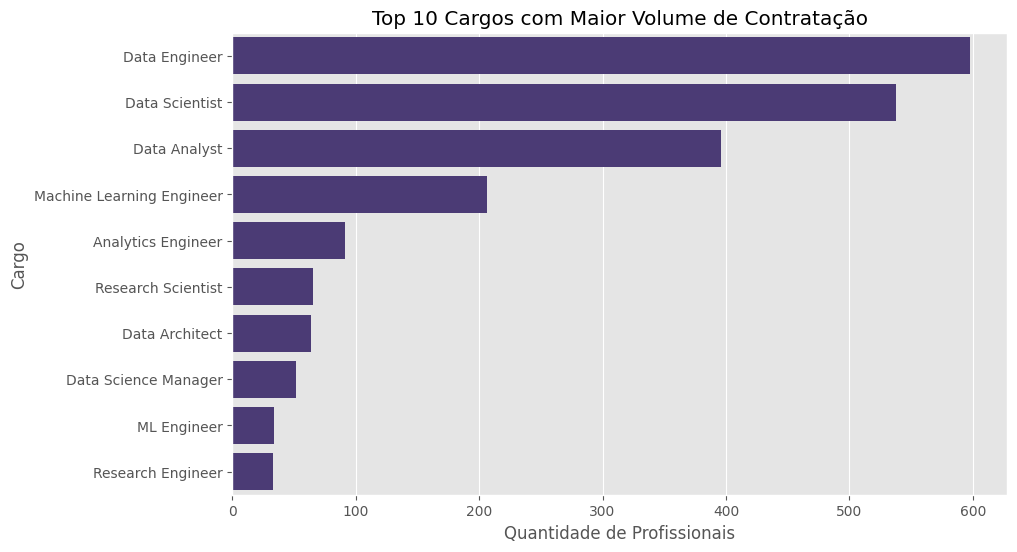

In [8]:
plt.figure(figsize=(10, 6))

# Isolando os 10 cargos com maior volume
top_cargos = df_clean['job_title'].value_counts().head(10)

# Gráfico de barras horizontais para facilitar a leitura
sns.barplot(x=top_cargos.values, y=top_cargos.index)

plt.title('Top 10 Cargos com Maior Volume de Contratação')
plt.xlabel('Quantidade de Profissionais')
plt.ylabel('Cargo')
plt.show()

#Bloco 7: Análise Bivariada (Relação Salário x Experiência)

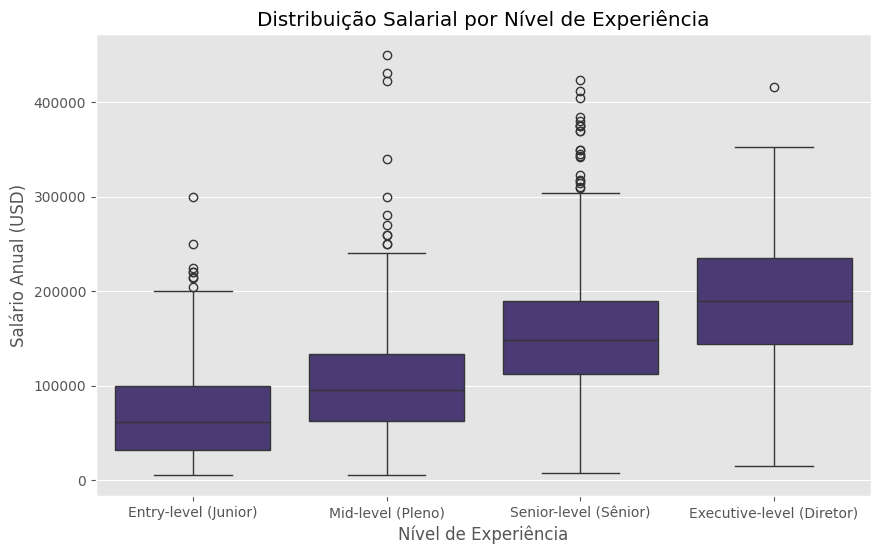

In [9]:
plt.figure(figsize=(10, 6))

# Definindo a ordem cronológica da carreira
ordem_experiencia = ['Entry-level (Junior)', 'Mid-level (Pleno)', 'Senior-level (Sênior)', 'Executive-level (Diretor)']

sns.boxplot(data=df_clean, x='experience_level', y='salary_in_usd', order=ordem_experiencia)

plt.title('Distribuição Salarial por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário Anual (USD)')
plt.show()

#Bloco 8: Análise de Tendência (Série Temporal Simples)

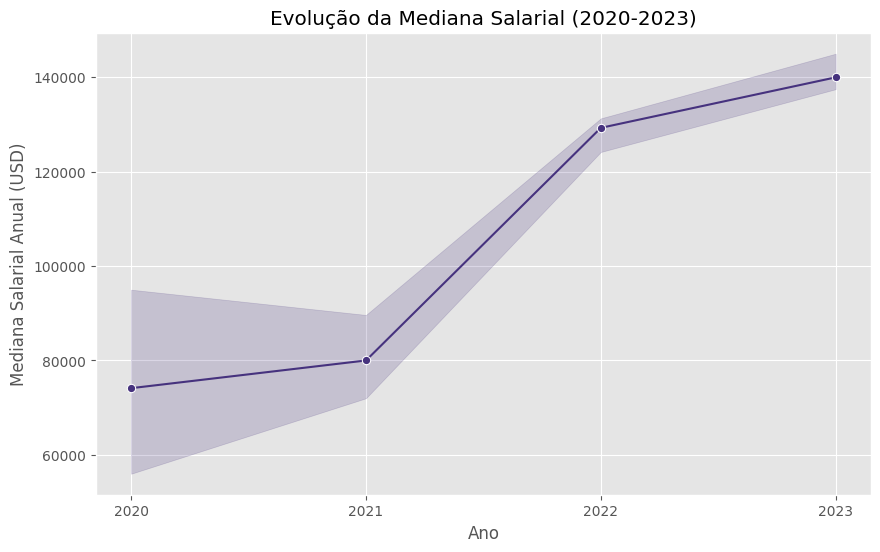

In [10]:
plt.figure(figsize=(10, 6))

# Gráfico de linha usando a mediana como agregador para evitar distorção por outliers
sns.lineplot(data=df_clean, x='work_year', y='salary_in_usd', estimator=np.median, marker='o')

plt.title('Evolução da Mediana Salarial (2020-2023)')
plt.xlabel('Ano')
plt.ylabel('Mediana Salarial Anual (USD)')

# Ajustando o eixo X para mostrar apenas os anos inteiros
plt.xticks(df_clean['work_year'].unique())
plt.show()

#Célula 9: Distribuição Salarial Global (Histograma)

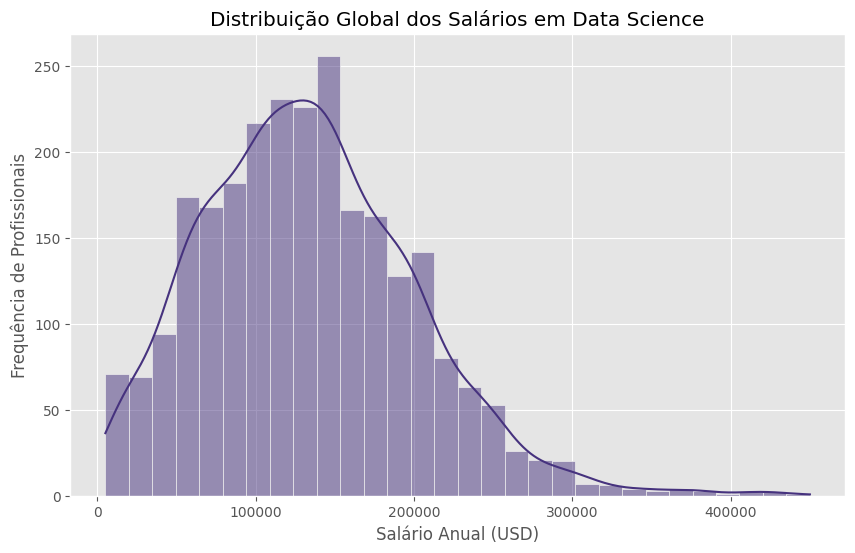

In [11]:
plt.figure(figsize=(10, 6))

# Histograma com linha de densidade (KDE)
sns.histplot(data=df_clean, x='salary_in_usd', kde=True, bins=30)

plt.title('Distribuição Global dos Salários em Data Science')
plt.xlabel('Salário Anual (USD)')
plt.ylabel('Frequência de Profissionais')
plt.show()

#Célula 10: Impacto do Tamanho da Empresa

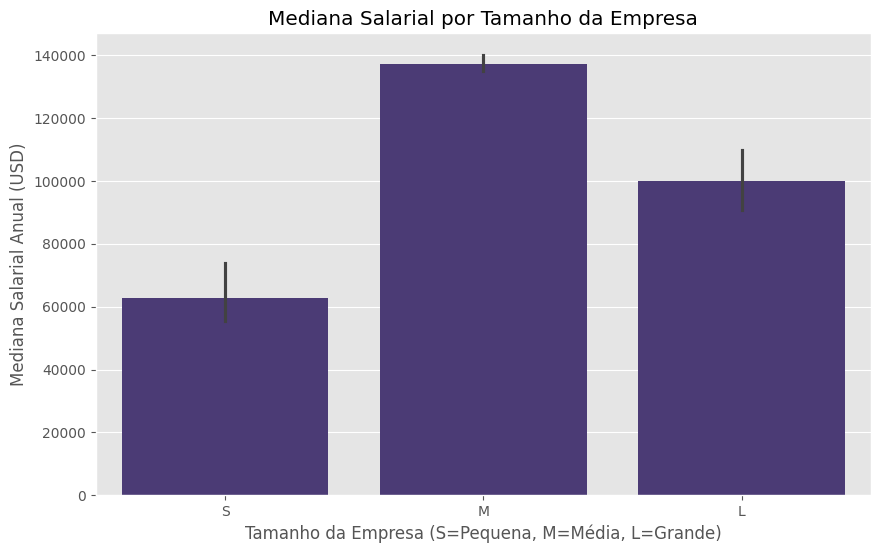

In [12]:
plt.figure(figsize=(10, 6))

# S: Pequena, M: Média, L: Grande
ordem_tamanho = ['S', 'M', 'L']

# Usando a mediana salarial para comparação justa
sns.barplot(data=df_clean, x='company_size', y='salary_in_usd', order=ordem_tamanho, estimator=np.median)

plt.title('Mediana Salarial por Tamanho da Empresa')
plt.xlabel('Tamanho da Empresa (S=Pequena, M=Média, L=Grande)')
plt.ylabel('Mediana Salarial Anual (USD)')
plt.show()